In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # For saving models
from tqdm import tqdm
import os

# ML classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier


In [ ]:
good = pd.read_excel('/content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/good_fish_df_automatic.xlsx')
bad = pd.read_excel('/content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/bad_fish_df_automatic.xlsx')

good.drop(good[good['fish_detected'] == 0].index, inplace=True)
bad.drop(bad[bad['fish_detected'] == 0].index, inplace=True)

cols_to_drop = ['norm_width_cm', 'norm_height_cm', 'distance_to_center_cm',
               'fish_detected', 'filename', 'filepath']

good.drop(columns=cols_to_drop, inplace=True)
bad.drop(columns=cols_to_drop, inplace=True)

good.shape, bad.shape

((446, 39), (448, 39))

In [ ]:
good.columns

Index(['height_cm', 'x_min', 'y_min', 'x_max', 'y_max', 'width', 'height',
       'diagonal_length', 'fish_area', 'image_area', 'seg_img_area',
       'fish_circumference', 'area_ratio', 'aspect_ratio',
       'diagonal_to_height_ratio', 'image_height', 'image_width', 'norm_width',
       'norm_height', 'norm_diagonal_length', 'centroid_x', 'centroid_y',
       'norm_centroid_x', 'norm_centroid_y', 'center_x', 'center_y',
       'distance_to_center', 'perimeter', 'compactness', 'width_cm',
       'diagonal_length_cm', 'fish_area_cm', 'image_area_cm',
       'seg_img_area_cm', 'fish_circumference_cm', 'image_height_cm',
       'image_width_cm', 'norm_diagonal_length_cm', 'perimeter_cm'],
      dtype='object')

In [ ]:
# Models dictionary
models = {
    "LogisticRegression": LogisticRegression(),
    "RandomForestClassifier": RandomForestClassifier(),
    "SVC": SVC(),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "GradientBoostingClassifier": GradientBoostingClassifier(),
    "GaussianNB": GaussianNB(),
    "XGBClassifier": XGBClassifier(),
    "AdaBoostClassifier": AdaBoostClassifier(),
    "ExtraTreesClassifier": ExtraTreesClassifier()
}

def prepare_data(good_df, bad_df):
    # Combine good and bad data, add a label column: 1 for good, 0 for bad
    good_df['label'] = 1
    bad_df['label'] = 0

    # Concatenate good and bad dataframes
    combined_df = pd.concat([good_df, bad_df], ignore_index=True)

    # Shuffle the data
    combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

    # Drop columns that are not features (like 'filename', 'filepath')
    X = combined_df.drop(columns=['label'])
    y = combined_df['label']

    return X, y

def train_and_evaluate_models(X, y, models, model_save_dir):
    # Split data into training and testing sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Standardize the features for models that require scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Save the scaler to a file
    scaler_file = f"{model_save_dir}/scaler_classification.pkl"
    joblib.dump(scaler, scaler_file)
    print(f"Saved scaler to {scaler_file}")

    # Train and evaluate models
    for model_name, model in tqdm(models.items()):
        # Use scaled data for models that benefit from scaling
        if model_name in ["LogisticRegression", "SVC", "KNeighborsClassifier",
                          "GradientBoostingClassifier", "XGBClassifier"]:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            # For tree-based models, use original data
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        # Save the model
        model_file = f"{model_save_dir}/{model_name}.pkl"
        joblib.dump(model, model_file)
        print(f"Saved {model_name} to {model_file}")

        # Plot confusion matrix
        plot_confusion_matrix(y_test, y_pred, model_name)

        # Print classification report
        print(f"Classification Report for {model_name}:\n")
        print(classification_report(y_test, y_pred, target_names=['Bad', 'Good']))

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [ ]:
good_df = good.sample(frac=1, random_state=42).reset_index(drop=True)
bad_df = bad.sample(frac=1, random_state=42).reset_index(drop=True)
model_save_dir = '/content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/Classification models'
os.makedirs(model_save_dir, exist_ok=True)

In [ ]:
unseen_X, unseen_y = prepare_data(good_df[:100], bad_df[:100])
print(unseen_X.shape, unseen_y.shape)

(200, 39) (200,)


<ipython-input-27-a4c25b39b09e>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_df['label'] = 1
<ipython-input-27-a4c25b39b09e>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bad_df['label'] = 0


In [ ]:
X, y = prepare_data(good_df[100:], bad_df[100:])
print(X.shape, y.shape)

(694, 39) (694,)


<ipython-input-27-a4c25b39b09e>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_df['label'] = 1
<ipython-input-27-a4c25b39b09e>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bad_df['label'] = 0


Saved scaler to /content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/models/scaler.pkl


  0%|          | 0/10 [00:00<?, ?it/s]

Saved LogisticRegression to /content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/models/LogisticRegression.pkl


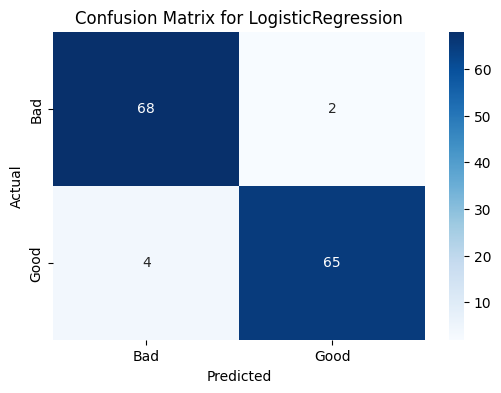

 10%|█         | 1/10 [00:01<00:12,  1.41s/it]

Classification Report for LogisticRegression:

              precision    recall  f1-score   support

         Bad       0.94      0.97      0.96        70
        Good       0.97      0.94      0.96        69

    accuracy                           0.96       139
   macro avg       0.96      0.96      0.96       139
weighted avg       0.96      0.96      0.96       139

Saved RandomForestClassifier to /content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/models/RandomForestClassifier.pkl


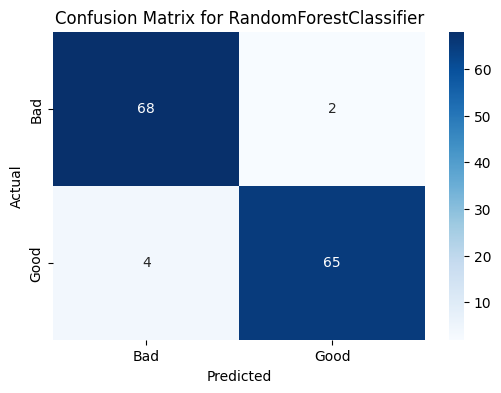

 20%|██        | 2/10 [00:02<00:09,  1.13s/it]

Classification Report for RandomForestClassifier:

              precision    recall  f1-score   support

         Bad       0.94      0.97      0.96        70
        Good       0.97      0.94      0.96        69

    accuracy                           0.96       139
   macro avg       0.96      0.96      0.96       139
weighted avg       0.96      0.96      0.96       139

Saved SVC to /content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/models/SVC.pkl


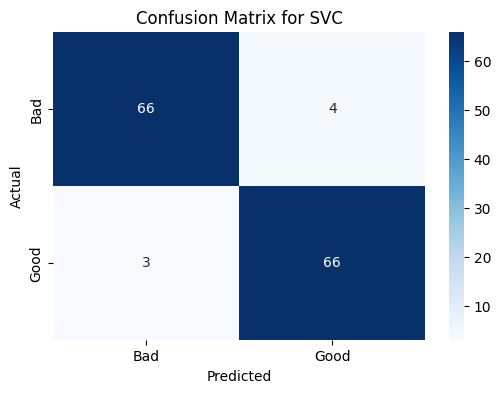

 30%|███       | 3/10 [00:02<00:05,  1.24it/s]

Classification Report for SVC:

              precision    recall  f1-score   support

         Bad       0.96      0.94      0.95        70
        Good       0.94      0.96      0.95        69

    accuracy                           0.95       139
   macro avg       0.95      0.95      0.95       139
weighted avg       0.95      0.95      0.95       139

Saved KNeighborsClassifier to /content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/models/KNeighborsClassifier.pkl


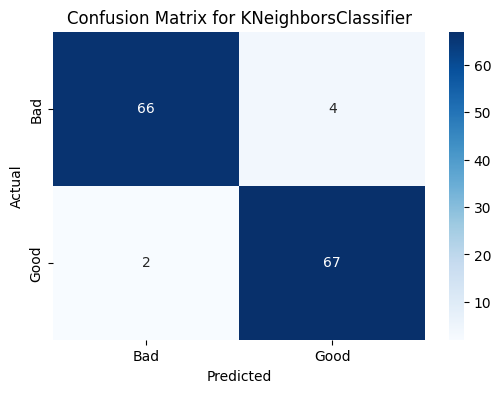

 40%|████      | 4/10 [00:03<00:04,  1.49it/s]

Classification Report for KNeighborsClassifier:

              precision    recall  f1-score   support

         Bad       0.97      0.94      0.96        70
        Good       0.94      0.97      0.96        69

    accuracy                           0.96       139
   macro avg       0.96      0.96      0.96       139
weighted avg       0.96      0.96      0.96       139

Saved DecisionTreeClassifier to /content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/models/DecisionTreeClassifier.pkl


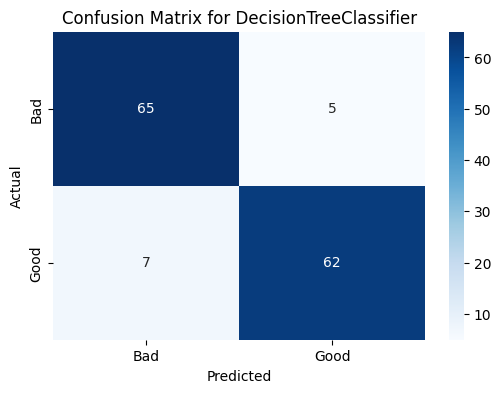

 50%|█████     | 5/10 [00:03<00:02,  1.77it/s]

Classification Report for DecisionTreeClassifier:

              precision    recall  f1-score   support

         Bad       0.90      0.93      0.92        70
        Good       0.93      0.90      0.91        69

    accuracy                           0.91       139
   macro avg       0.91      0.91      0.91       139
weighted avg       0.91      0.91      0.91       139

Saved GradientBoostingClassifier to /content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/models/GradientBoostingClassifier.pkl


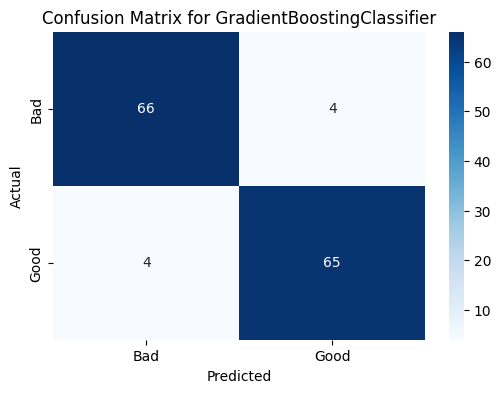

 60%|██████    | 6/10 [00:05<00:03,  1.16it/s]

Classification Report for GradientBoostingClassifier:

              precision    recall  f1-score   support

         Bad       0.94      0.94      0.94        70
        Good       0.94      0.94      0.94        69

    accuracy                           0.94       139
   macro avg       0.94      0.94      0.94       139
weighted avg       0.94      0.94      0.94       139

Saved GaussianNB to /content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/models/GaussianNB.pkl


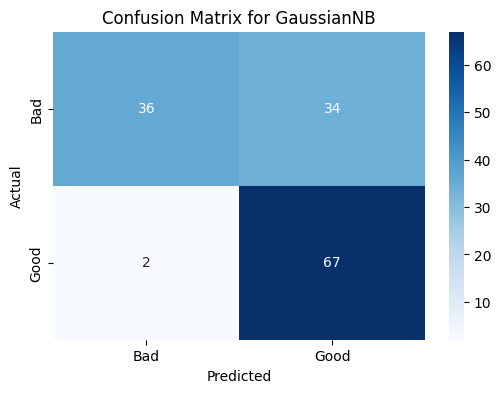

 70%|███████   | 7/10 [00:05<00:02,  1.48it/s]

Classification Report for GaussianNB:

              precision    recall  f1-score   support

         Bad       0.95      0.51      0.67        70
        Good       0.66      0.97      0.79        69

    accuracy                           0.74       139
   macro avg       0.81      0.74      0.73       139
weighted avg       0.81      0.74      0.73       139

Saved XGBClassifier to /content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/models/XGBClassifier.pkl


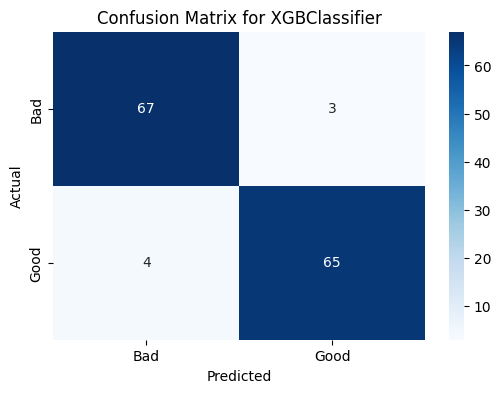

 80%|████████  | 8/10 [00:05<00:01,  1.71it/s]

Classification Report for XGBClassifier:

              precision    recall  f1-score   support

         Bad       0.94      0.96      0.95        70
        Good       0.96      0.94      0.95        69

    accuracy                           0.95       139
   macro avg       0.95      0.95      0.95       139
weighted avg       0.95      0.95      0.95       139



/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Saved AdaBoostClassifier to /content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/models/AdaBoostClassifier.pkl


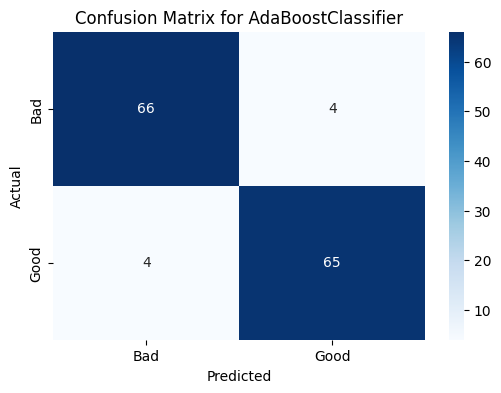

 90%|█████████ | 9/10 [00:06<00:00,  1.69it/s]

Classification Report for AdaBoostClassifier:

              precision    recall  f1-score   support

         Bad       0.94      0.94      0.94        70
        Good       0.94      0.94      0.94        69

    accuracy                           0.94       139
   macro avg       0.94      0.94      0.94       139
weighted avg       0.94      0.94      0.94       139

Saved ExtraTreesClassifier to /content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/models/ExtraTreesClassifier.pkl


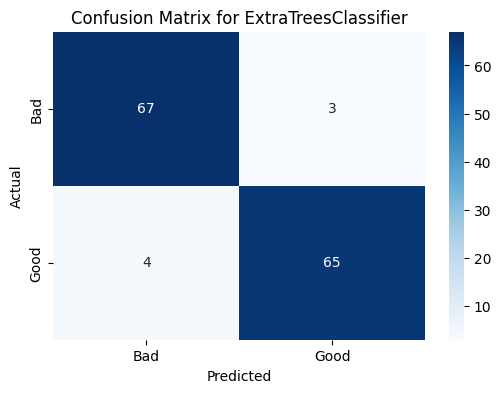

100%|██████████| 10/10 [00:07<00:00,  1.41it/s]

Classification Report for ExtraTreesClassifier:

              precision    recall  f1-score   support

         Bad       0.94      0.96      0.95        70
        Good       0.96      0.94      0.95        69

    accuracy                           0.95       139
   macro avg       0.95      0.95      0.95       139
weighted avg       0.95      0.95      0.95       139



In [ ]:
train_and_evaluate_models(X, y, models, model_save_dir)

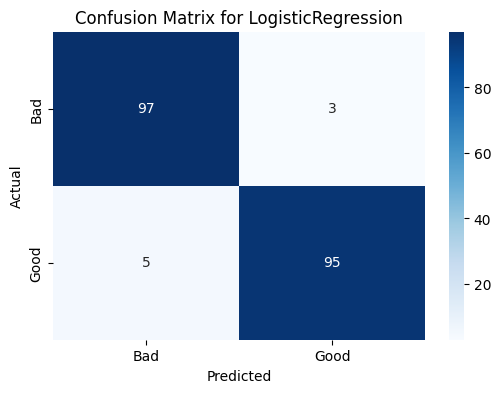

Classification Report for LogisticRegression on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.95      0.97      0.96       100
        Good       0.97      0.95      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



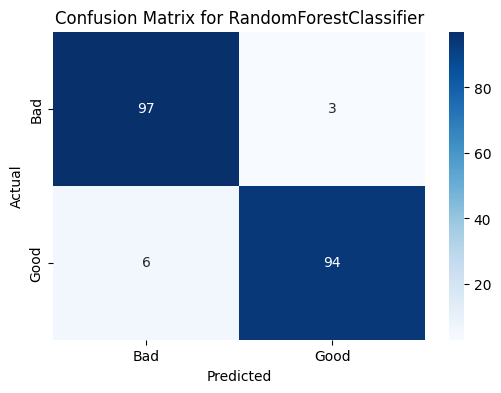

Classification Report for RandomForestClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.94      0.97      0.96       100
        Good       0.97      0.94      0.95       100

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.96      0.95      0.95       200



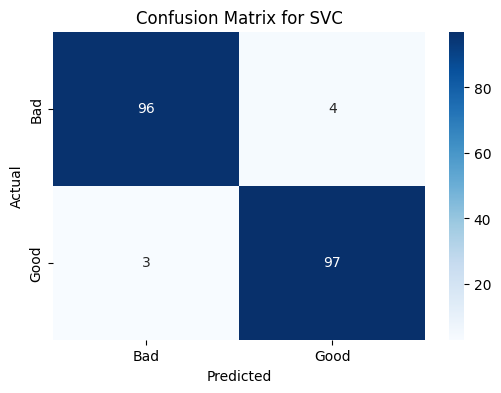

Classification Report for SVC on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.97      0.96      0.96       100
        Good       0.96      0.97      0.97       100

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200



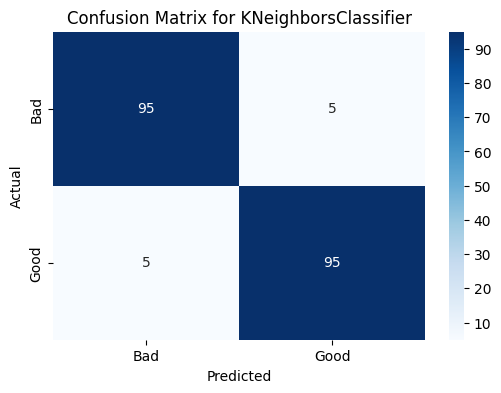

Classification Report for KNeighborsClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.95      0.95      0.95       100
        Good       0.95      0.95      0.95       100

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



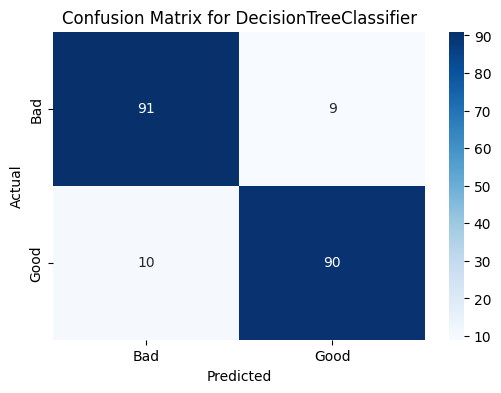

Classification Report for DecisionTreeClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.90      0.91      0.91       100
        Good       0.91      0.90      0.90       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.90       200



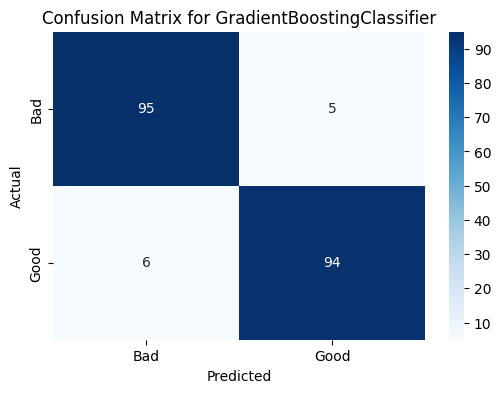

Classification Report for GradientBoostingClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.94      0.95      0.95       100
        Good       0.95      0.94      0.94       100

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.95      0.94      0.94       200



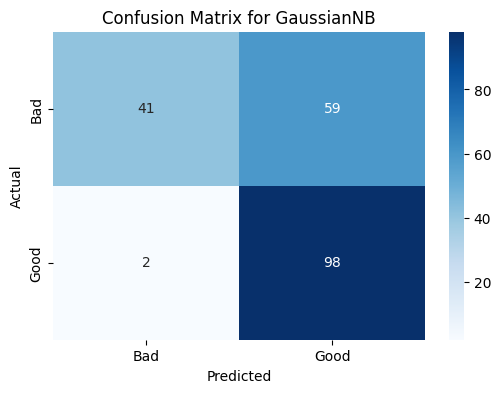

Classification Report for GaussianNB on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.95      0.41      0.57       100
        Good       0.62      0.98      0.76       100

    accuracy                           0.69       200
   macro avg       0.79      0.69      0.67       200
weighted avg       0.79      0.69      0.67       200



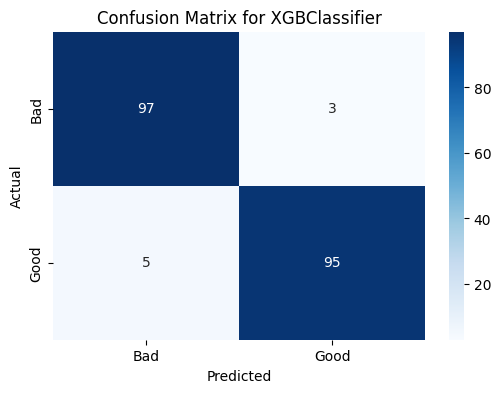

Classification Report for XGBClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.95      0.97      0.96       100
        Good       0.97      0.95      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



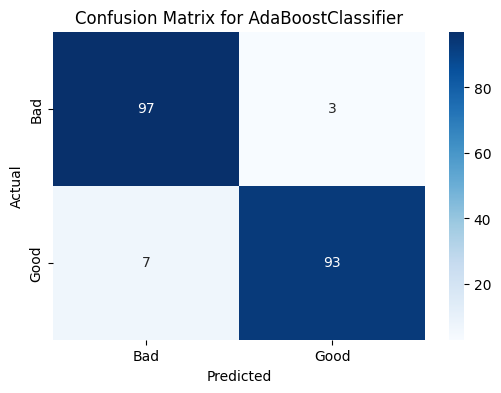

Classification Report for AdaBoostClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.93      0.97      0.95       100
        Good       0.97      0.93      0.95       100

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



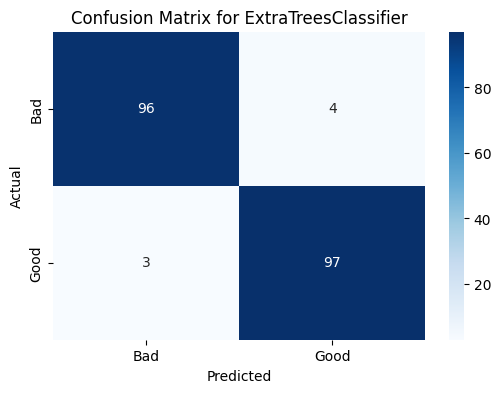

Classification Report for ExtraTreesClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.97      0.96      0.96       100
        Good       0.96      0.97      0.97       100

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200



In [ ]:
def load_and_evaluate_models(unseen_X, unseen_y, model_save_dir, model_names, scaler_path=None):
    # Load the scaler or preprocessor if it exists
    if scaler_path:
        scaler = joblib.load(scaler_path)
        unseen_X_scaled = scaler.transform(unseen_X)  # Apply the same scaling to unseen data

    # Iterate over all the saved models and evaluate them
    for model_name in model_names:
        # Load the model from the file
        model_path = f"{model_save_dir}/{model_name}.pkl"
        model = joblib.load(model_path)
        if model_name in ["LogisticRegression", "SVC", "KNeighborsClassifier",
                  "GradientBoostingClassifier", "XGBClassifier"]:
            y_pred = model.predict(unseen_X_scaled)
        else:
            # For tree-based models, use original data
            y_pred = model.predict(unseen_X)

        # Plot confusion matrix
        plot_confusion_matrix(unseen_y, y_pred, model_name)

        # Print classification report
        print(f"Classification Report for {model_name} on Unseen Data:\n")
        print(classification_report(unseen_y, y_pred, target_names=['Bad', 'Good']))


# Example usage
model_save_dir = '/content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/Classification models'
scaler_path = '/content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/Classification models/scaler_classification.pkl'  # Path to the saved scaler used during training

model_names = [
    "LogisticRegression", "RandomForestClassifier", "SVC", "KNeighborsClassifier",
    "DecisionTreeClassifier", "GradientBoostingClassifier", "GaussianNB",
    "XGBClassifier", "AdaBoostClassifier", "ExtraTreesClassifier"
]

# Evaluate all saved models on unseen data
load_and_evaluate_models(unseen_X, unseen_y, model_save_dir, model_names, scaler_path=scaler_path)
